## 9814 A2: Safe Interactive Reinforcement Learning
### Author: Songyu Qi
### Zid: z5536858

### Task 1: Safe Grid World Environment Setup
Env configration:

Grid Size: 10, 10

start position: 0, 0

Goal position: 9, 9

Action[4]

Reward structure: +10, -10, -0.1;

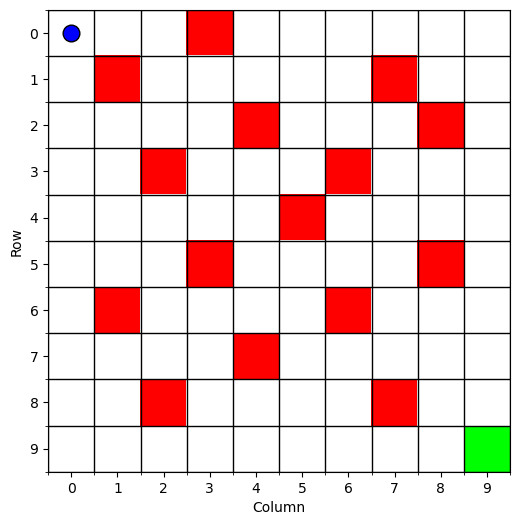

start: (0, 0)


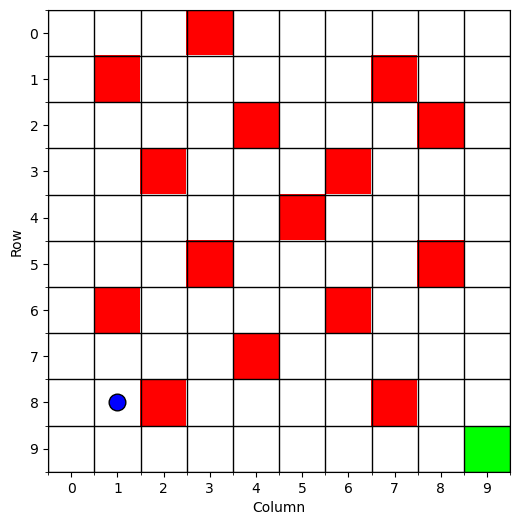

random start: (8, 1)


In [1]:
import numpy as np
import random
import time 
import sys  
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

class SafeGridWorld:
    """
    (row, col)
    fixed start position: (0, 0) left-top corner
    goal position: (9, 9) right-bottom corner
    action 0 (UP) = row - 1
    action 1 (DOWN) = row + 1
    action 2 (LEFT) = col - 1
    action 3 (RIGHT) = col + 1
    """
    
    def __init__(self, random_start: bool = False):
        self.grid_size = (10, 10)
        self.rows, self.cols = self.grid_size

        self.start_pos = (0, 0)
        self.goal_pos = (9, 9)

        self.hazard_cells = set([
            (0, 3), (1, 1), (1, 7), (2, 4), (2, 8),
            (3, 2), (3, 6), (4, 5), (5, 3), (5, 8),
            (6, 1), (6, 6), (7, 4), (8, 2), (8, 7)
        ]) 

        # 0: UP, 1: DOWN, 2: LEFT, 3: RIGHT
        self.action_space_size = 4
        # (dr, dc)
        self.actions = {
            0: (-1, 0), # UP
            1: (1, 0),  # DOWN
            2: (0, -1), # LEFT
            3: (0, 1)   # RIGHT
        }

        self.goal_reward = 10.0      
        self.hazard_reward = -10.0  
        self.step_penalty = -0.1     

        self.random_start = random_start 
        self.safe_start_positions = self.get_safe_starts()

        self.current_position = None
        self.reset() 

        # --- for rendering ---
        # 0: normal, 1: hazard, 2: goal
        self.grid_data = np.zeros(self.grid_size)
        for h in self.hazard_cells:
            self.grid_data[h] = 1
        self.grid_data[self.goal_pos] = 2
        
        # white, red, green
        self.cmap = ListedColormap(['#FFFFFF', '#FF0000', '#00FF00'])
        self.norm = plt.Normalize(vmin=0, vmax=2)

    def get_safe_starts(self) -> list:
        """
        precompute all valid random start positions.
        a position is valid if it is not a hazard or goal.
        """
        safe_starts = []

        for r in range(self.rows):
            for c in range(self.cols):
                pos = (r, c)
                if pos != self.goal_pos and pos not in self.hazard_cells:
                    safe_starts.append(pos)
                    
        if len(safe_starts) != 84:
            print(f"Wrong calculate for the safe points")
            
        return safe_starts

    def reset(self) -> tuple:
        """
        reset the environment to an initial state.
        according to the self.random_start flag to decide if the start position is fixed or random.
        
        return:
            tuple: initial state (row, col)
        """

        if self.random_start:
            self.current_position = random.choice(self.safe_start_positions)
        else:
            self.current_position = self.start_pos
            
        return self.current_position

    def step(self, action: int) -> (tuple, float, bool):
        """
        execute an action, update the environment state.

        parameters:
            action (int): 0, 1, 2, 3 

        return:
            tuple: (next_state, reward, done)
                next_state (tuple): new state (row, col)
                reward (float): reward
                done (bool): if the episode is over
        """

        dr, dc = self.actions[action]
        
        current_r, current_c = self.current_position
        next_r, next_c = current_r + dr, current_c + dc

        if not (0 <= next_r < self.rows and 0 <= next_c < self.cols): #stay in the same position
            final_position = self.current_position
        else:
            final_position = (next_r, next_c)
            final_position = (next_r, next_c)

        reward = self.step_penalty
        done = False
        
        if final_position in self.hazard_cells:
            reward = self.hazard_reward
            done = True
        elif final_position == self.goal_pos:
            reward = self.goal_reward
            done = True
            
        self.current_position = final_position     
        return (self.current_position, reward, done)

    def render(self):
        """
        Render the environment using Matplotlib.
        """
        fig, ax = plt.subplots(figsize=(6, 6))
        
        # Draw the grid
        ax.imshow(self.grid_data, cmap=self.cmap, norm=self.norm, interpolation='nearest')

        # Draw the agent
        agent_row, agent_col = self.current_position
        
        # Special markers for terminal states
        if self.current_position == self.goal_pos:
            marker = 'P' 
            color = 'blue'
        elif self.current_position in self.hazard_cells:
            marker = 'X'
            color = 'black'
        else:
            marker = 'o'
            color = 'blue'
            
        ax.plot(agent_col, agent_row, marker, markersize=12, color=color, markeredgecolor='black')

        # Grid lines
        ax.set_xticks(np.arange(-.5, self.cols, 1), minor=True)
        ax.set_yticks(np.arange(-.5, self.rows, 1), minor=True)
        ax.grid(which='minor', color='black', linestyle='-', linewidth=1)
        
        # Axis labels
        ax.set_xlabel("Column")
        ax.set_ylabel("Row")
        ax.set_xticks(np.arange(0, self.cols, 1))
        ax.set_yticks(np.arange(0, self.rows, 1))
        
        plt.show()


env_fixed = SafeGridWorld(random_start=False)
state = env_fixed.reset()
env_fixed.render()
print(f"start: {state}")


env_random = SafeGridWorld(random_start=True)
state = env_random.reset()
env_random.render()
print(f"random start: {state}")


### Task2: implement Q-learning
Parameter from spec

When training, need decay after each episodes, Q-table only update lot in beginning

                          Penalty = -1.0 (Harsh)  Penalty = -0.1 (Gentle)
Metric                                                                   
Success Rate (%)                            0.00                    97.80
Avg Reward (Last 25%)                      -7.54                     7.86
Avg Length (Last 25%)                      18.02                    17.97
Total Violations                          559.00                   499.00
Training Speed (eps/sec)                17086.55                 17408.30


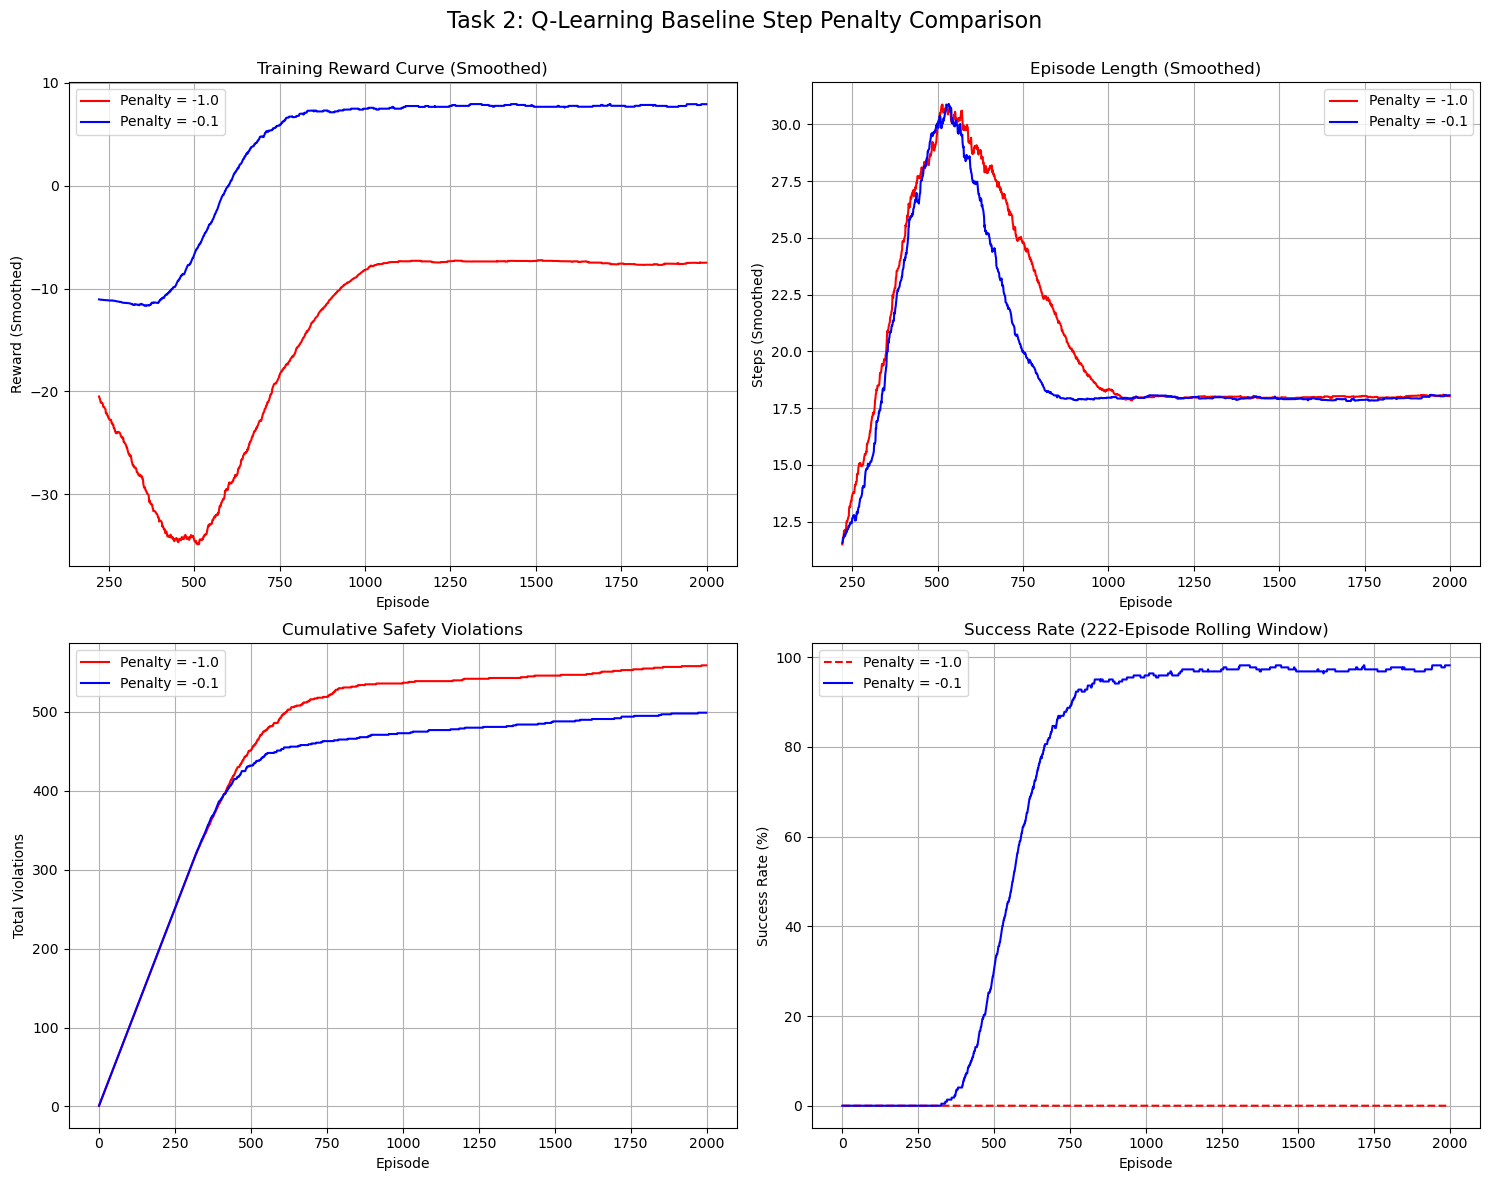

In [ ]:
import pandas as pd
class QLearningAgent:
    """
    Implement a agent using Q-Learning
    """
    def __init__(self, state_space, action_space_size, params):
        self.rows, self.cols = state_space
        self.action_space_size = action_space_size
        
        self.q_table = np.zeros((self.rows, self.cols, self.action_space_size))
        
        self.alpha = params['alpha'] #learning rate
        self.gamma = params['gamma'] #discount factor [0, 1], 0: only now; ->1 can look too far
        self.epsilon = params['epsilon_start'] #exploration rate: for exploration, inplement epsilon-greedy
        self.epsilon_min = params['epsilon_min']
        self.epsilon_decay = params['epsilon_decay']

    def choose_action(self, state) -> int:
        """
        Use Epsilon-Greedy strategy to choose an action.
        """
        row, col = state
        # Explore
        if random.uniform(0, 1) < self.epsilon:
            return random.randint(0, self.action_space_size - 1)
        # Exploit
        else:
            return np.argmax(self.q_table[row, col, :])

    def update_q_table(self, state, action, reward, next_state, done):
        """
        Use Q-Learning update rule to update Q-Table.
        """
        row, col = state
        next_row, next_col = next_state
        
        old_q_value = self.q_table[row, col, action]
        
        # calculate future max q value
        if done: # in goal or hazard
            future_q_max = 0.0
        else:
            future_q_max = np.max(self.q_table[next_row, next_col, :])
            
        # TD target (r + gamma * max_a' Q(s', a'))
        td_target = reward + self.gamma * future_q_max
        
        # calculate new Q-Value
        new_q_value = old_q_value + self.alpha * (td_target - old_q_value)
        
        # update Q-Table
        self.q_table[row, col, action] = new_q_value

    def decay_epsilon(self):
        """ decay Epsilon."""
        self.epsilon = max(self.epsilon_min, self.epsilon * self.epsilon_decay)

# =============================================================================
# TASK 2: EXPERIMENT RUNNER & HELPERS
# =============================================================================

def smooth(data, window_size):
    if window_size <= 0:
        return data
    # use 'valid' mode to ensure the number of data points is correct
    return np.convolve(data, np.ones(window_size)/window_size, mode='valid')

def run_experiment(params, penalty_value, visualize=False):
    """
    Run a complete Q-Learning training experiment.
    """

    env = SafeGridWorld(random_start=False)
    env.step_penalty = penalty_value  # -1.0 / -0.1
    
    agent = QLearningAgent(
        state_space=env.grid_size,
        action_space_size=env.action_space_size,
        params=params
    )
    
    # training log
    all_episode_rewards = []
    all_episode_lengths = []
    all_episode_violations = []
    cumulative_violations = 0
    cumulative_violations_log = []

    start_time = time.time()

    for episode in range(params['N_EPISODES']):
        state = env.reset()
        
        total_reward = 0
        steps = 0
        violations = 0
        done = False
        
        while not done and steps < params['MAX_STEPS']:
            action = agent.choose_action(state)
            next_state, reward, done = env.step(action)
            agent.update_q_table(state, action, reward, next_state, done)
            
            total_reward += reward
            steps += 1
            state = next_state
            
            if reward == env.hazard_reward:
                violations += 1
            
        agent.decay_epsilon() # as q-table is more full, epsilon is more likely to be smaller
        
        all_episode_rewards.append(total_reward)
        all_episode_lengths.append(steps)
        all_episode_violations.append(violations)
        cumulative_violations += violations
        cumulative_violations_log.append(cumulative_violations)
            
    end_time = time.time()
    
    if visualize:
        env.close()
    
    results = {
        'rewards': np.array(all_episode_rewards),
        'lengths': np.array(all_episode_lengths),
        'violations': np.array(all_episode_violations),
        'cumulative_violations': np.array(cumulative_violations_log),
        'total_time': end_time - start_time,
        'label': f"Penalty = {penalty_value}"
    }
    return results, agent.q_table

def calculate_metrics(results, N, M):
    """
    Calculate all 5 evaluation metrics.
    M is the number of last 25% episodes.
    """
    last_M_rewards = results['rewards'][-M:]
    last_M_lengths = results['lengths'][-M:]
    
    # success rate: reward > 0
    success_rate = np.mean(last_M_rewards > 0) * 100 
    
    # average reward
    avg_reward = np.mean(last_M_rewards)
    
    # average episode length
    avg_length = np.mean(last_M_lengths)
    
    # total violations
    total_violations = np.sum(results['violations'])
    
    # training speed
    training_speed = N / results['total_time']
    
    metrics = {
        'Success Rate (%)': success_rate,
        'Avg Reward (Last 25%)': avg_reward,
        'Avg Length (Last 25%)': avg_length,
        'Total Violations': total_violations,
        'Training Speed (eps/sec)': training_speed
    }
    return metrics

def plot_results(res_A, res_B, window_size=200):
  
    fig, axes = plt.subplots(2, 2, figsize=(15, 12))
    fig.suptitle('Task 2: Q-Learning Baseline Step Penalty Comparison', fontsize=16)

    ax = axes[0, 0]
    x_axis_A = np.arange(window_size - 1, len(res_A['rewards']))
    x_axis_B = np.arange(window_size - 1, len(res_B['rewards']))
    
    ax.plot(x_axis_A, smooth(res_A['rewards'], window_size), label=res_A['label'], color='red')
    ax.plot(x_axis_B, smooth(res_B['rewards'], window_size), label=res_B['label'], color='blue')
    ax.set_title('Training Reward Curve (Smoothed)')
    ax.set_xlabel('Episode')
    ax.set_ylabel('Reward (Smoothed)')
    ax.legend()
    ax.grid(True)

    # Episode Length
    ax = axes[0, 1]
    ax.plot(x_axis_A, smooth(res_A['lengths'], window_size), label=res_A['label'], color='red')
    ax.plot(x_axis_B, smooth(res_B['lengths'], window_size), label=res_B['label'], color='blue')
    ax.set_title('Episode Length (Smoothed)')
    ax.set_xlabel('Episode')
    ax.set_ylabel('Steps (Smoothed)')
    ax.legend()
    ax.grid(True)

    # number of violations
    ax = axes[1, 0]
    ax.plot(res_A['cumulative_violations'], label=res_A['label'], color='red')
    ax.plot(res_B['cumulative_violations'], label=res_B['label'], color='blue')
    ax.set_title('Cumulative Safety Violations')
    ax.set_xlabel('Episode')
    ax.set_ylabel('Total Violations')
    ax.legend()
    ax.grid(True)

    # success rate
    success_A = pd.Series(res_A['rewards'] > 0).rolling(window_size, min_periods=1).mean() * 100
    success_B = pd.Series(res_B['rewards'] > 0).rolling(window_size, min_periods=1).mean() * 100
    
    ax = axes[1, 1]
    ax.plot(success_A, label=res_A['label'], color='red', linestyle='--')
    ax.plot(success_B, label=res_B['label'], color='blue')
    ax.set_title(f'Success Rate ({window_size}-Episode Rolling Window)')
    ax.set_xlabel('Episode')
    ax.set_ylabel('Success Rate (%)')
    ax.legend()
    ax.grid(True)

    plt.tight_layout()
    plt.subplots_adjust(top=0.92)
    plt.savefig("task2_comparison_plots.png")
    plt.show()

# =============================================================================
# TASK 2: MAIN EXECUTION
# =============================================================================
SEED = 66
random.seed(SEED)
np.random.seed(SEED)
PARAMS = {
    'alpha': 0.1,
    'gamma': 0.99,
    'epsilon_start': 1.0,
    'epsilon_min': 0.01,
    'epsilon_decay': 0.995,
    'N_EPISODES': 2000,
    'MAX_STEPS': 200,
}

# Calculate the last 25% of metrics
M_last_25_percent = int(PARAMS['N_EPISODES'] * 0.25)


# harsh penalty (-1.0) 
results_harsh, q_table_harsh = run_experiment(PARAMS, penalty_value=-1.0, visualize=False)

# gentle penalty (-0.1)
results_gentle, q_table_gentle = run_experiment(PARAMS, penalty_value=-0.1, visualize=False)

metrics_harsh = calculate_metrics(results_harsh, PARAMS['N_EPISODES'], M_last_25_percent)
metrics_gentle = calculate_metrics(results_gentle, PARAMS['N_EPISODES'], M_last_25_percent)

df_metrics = pd.DataFrame({
    'Metric': metrics_harsh.keys(),
    'Penalty = -1.0 (Harsh)': metrics_harsh.values(),
    'Penalty = -0.1 (Gentle)': metrics_gentle.values()
}).set_index('Metric')

pd.set_option('display.float_format', '{:.2f}'.format)
print(df_metrics)

plot_results(results_harsh, results_gentle, window_size=222)

#gentle is better
np.save("task2_q_table_gentle.npy", q_table_gentle)

### Task3
- use multiple oringal BFS to calculate the damage map(every hazard is a oringal)
- prepare 10-dimention DataSet:
    - every safe state with 4 action. 84 * 4 = 336

One problem:
- the 10th dimention will cause data leaking

In [ ]:
import numpy as np
import pickle
from collections import deque
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

def _get_next_state(env, state, action):
    """
    calculate the deterministic transition of (s, a) -> s'
    do not modify the internal state of the environment.
    """
    dr, dc = env.actions[action]
    current_r, current_c = state
    next_r, next_c = current_r + dr, current_c + dc

    if not (0 <= next_r < env.rows and 0 <= next_c < env.cols):
        final_position = state #keep
    else:
        final_position = (next_r, next_c)
    return final_position

def _one_hot(action, num_actions=4):
    """ 
    transfer to one-hot vector
    [0, 0, 0, 0]
    [1, 0, 0, 0]
    [0, 1, 0, 0]
    [0, 0, 1, 0]
    [0, 0, 0, 1]
    """
    vec = np.zeros(num_actions)
    vec[action] = 1.0
    return vec

# =============================================================================
# COMPUTE DANGER MAP
# =============================================================================
def compute_danger_map(env):
    """
    use multiple BFS to calculate the global danger map
    """

    danger_map = np.full(env.grid_size, np.inf)
    queue = deque()

    #put all hazards in queue 
    for h in env.hazard_cells:
        danger_map[h] = 0
        queue.append((h, 0)) # (position, distance)

    while queue:
        current_pos, distance = queue.popleft()
        
        for action in env.actions.keys():
            dr, dc = env.actions[action]
            nr, nc = current_pos[0] + dr, current_pos[1] + dc
            neighbor_pos = (nr, nc)
            
            if not (0 <= nr < env.rows and 0 <= nc < env.cols):
                continue
                
            if danger_map[neighbor_pos] == np.inf:
                danger_map[neighbor_pos] = distance + 1
                queue.append((neighbor_pos, distance + 1))
    return danger_map

def generate_labeled_samples(env, danger_map):
    """
    run all (s, a) pairs, use danger map to generate label
    """
    raw_dataset = []
    for r in range(env.rows):
        for c in range(env.cols):
            s = (r, c)
            # skip terminal state (hazard or goal)
            if s in env.hazard_cells or s == env.goal_pos:
                continue
                
            for a in env.actions.keys():
                s_prime = _get_next_state(env, s, a)
                
                # query danger value d = D(s') 
                d = danger_map[s_prime]
                
                # assign category c
                if d == 0:
                    c = 0 # immediate danger
                elif d == 1:
                    c = 1 
                elif d == 2:
                    c = 2 
                else: # d >= 3 or d == np.inf
                    c = 3 # safe
                raw_dataset.append((s, a, c))
    
    # 84 safe states * 4 actions = 336 samples
    return raw_dataset

# =============================================================================
# STEP 3: FEATURE EXTRACTION & SPLITTING
# =============================================================================
def create_feature_dataset(raw_dataset, danger_map, env):
    """
    transfer (s, a, c) samples to 10-d feature vector and split
    """
    X = []
    y = []
    
    # normalize constant
    norm_pos = env.rows - 1.0 # divide by 9.0
    norm_dist = 10.0 
    
    for (s, a, c) in raw_dataset:
        r, c_col = s
        s_prime = _get_next_state(env, s, a)
        r_prime, c_prime = s_prime
        
        features = [
            r / norm_pos,                      # [0] current r 
            c_col / norm_pos,                  # [1] current c 
            *_one_hot(a, env.action_space_size), # [2-5] action one-hot 
            r_prime / norm_pos,                # [6] next r 
            c_prime / norm_pos,                # [7] next c 
            danger_map[s] / norm_dist,         # [8] D(s) 
            danger_map[s_prime] / norm_dist    # [9] D(s')
        ]
        
        X.append(features)
        y.append(c)
        
    X = np.array(X)
    y = np.array(y)
    
    print(f"[Task 3, Step 3] X shape: {X.shape}, y shape: {y.shape}")
    
    X_train_val, X_test, y_train_val, y_test = train_test_split(
        X, y, 
        test_size=0.15, 
        random_state=42,
        stratify=y #Stratified Sampling
    )
    
    val_split_ratio = 0.15 / (1.0 - 0.15) # approx 0.1765
    
    X_train, X_val, y_train, y_val = train_test_split(
        X_train_val, y_train_val,
        test_size=val_split_ratio,
        random_state=42,
        stratify=y_train_val
    )
    
    print(f"  Train set: {X_train.shape}, {y_train.shape} (~{len(y_train)/len(y)*100:.1f}%)")
    print(f"  Val set:   {X_val.shape}, {y_val.shape} (~{len(y_val)/len(y)*100:.1f}%)")
    print(f"  Test set:  {X_test.shape}, {y_test.shape} (~{len(y_test)/len(y)*100:.1f}%)")

    return (X_train, y_train, X_val, y_val, X_test, y_test)

# =============================================================================
# TASK 3: MAIN EXECUTION
# =============================================================================
env_for_task3 = SafeGridWorld(random_start=False)
danger_map = compute_danger_map(env_for_task3)
raw_dataset = generate_labeled_samples(env_for_task3, danger_map)

dataset_splits = (X_train, y_train, X_val, y_val, X_test, y_test) = \
    create_feature_dataset(raw_dataset, danger_map, env_for_task3)

dataset_filename = "complete_dataset.pkl"
with open(dataset_filename, 'wb') as f:
    pickle.dump(dataset_splits, f)

[Task 3, Step 3] X shape: (336, 10), y shape: (336,)
  Train set: (234, 10), (234,) (~69.6%)
  Val set:   (51, 10), (51,) (~15.2%)
  Test set:  (51, 10), (51,) (~15.2%)


## Task4 : MLP
Multi-layer perceptron to predict risk(s, a_prop)

Architecture:
- Input layer: 10
- Hidden layer 1: 64 (baseline value) 
- Activation: ReLU
- Hidden layer 2: 64 (baseline value) 
- Activation: ReLU
- Output layer: 4 (corresponding to 4 risk categories) 
- Output fuc: softmax(include in nn.CrossEntropyLoss)
- Loss function is Cross Entropy and the output activate function is softmax. (both in nn.CrossEntropyLoss)

  Epoch [10/100], Train Loss: 1.1668, Val Loss: 1.1842
  Epoch [20/100], Train Loss: 1.0667, Val Loss: 1.0769
  Epoch [30/100], Train Loss: 0.8247, Val Loss: 0.8535
  Epoch [40/100], Train Loss: 0.5619, Val Loss: 0.6145
  Epoch [50/100], Train Loss: 0.3456, Val Loss: 0.3788
  Epoch [60/100], Train Loss: 0.1926, Val Loss: 0.2147
  Epoch [70/100], Train Loss: 0.1060, Val Loss: 0.1229
  Epoch [80/100], Train Loss: 0.0627, Val Loss: 0.0758
  Epoch [90/100], Train Loss: 0.0390, Val Loss: 0.0497
  Epoch [100/100], Train Loss: 0.0273, Val Loss: 0.0340

 Task 4: Evaluate metrics (Test Set)
  Overall Accuracy: 100.00%

  Per-Class Accuracy:
    Class 0 (Hazard): 100.00%
    Class 1 (1-Step): 100.00%
    Class 2 (2-Step): 100.00%
    Class 3 (Safe)  : 100.00%

  [Success] Class 0 accuracy (100.00%) has reached the target of > 95%.



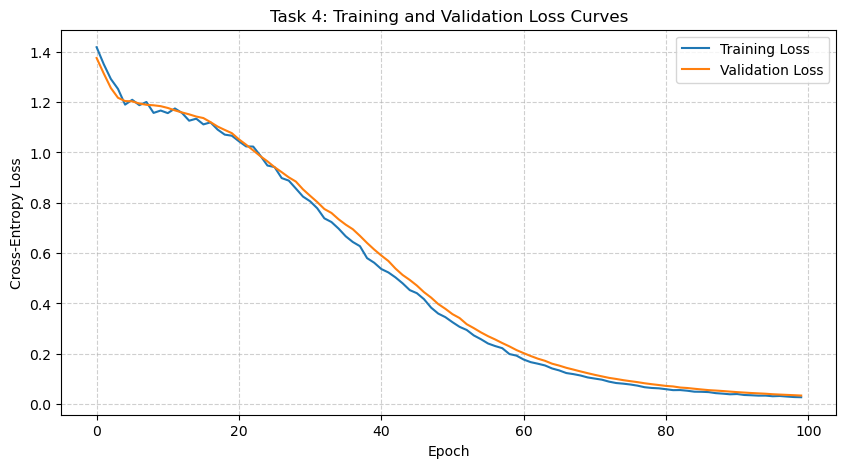

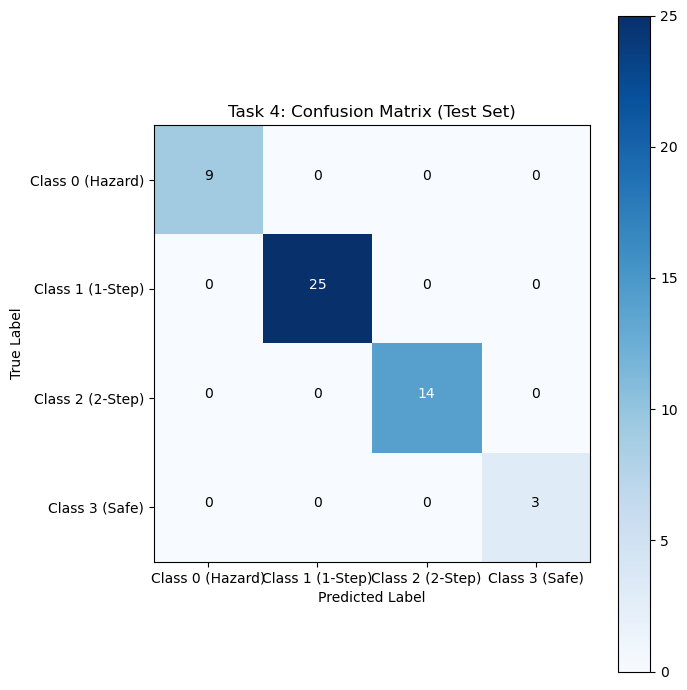

In [ ]:
import numpy as np
import pickle
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import itertools 

# =============================================================================
# TASK 4: DEFINE THE NEURAL NETWORK
# =============================================================================

class SafetyShieldNN(nn.Module):
    """
    Multi-layer perceptron to predict risk(s, a_prop)
    
    Architecture:
    - Input layer: 10
    - Hidden layer 1: 64 (baseline value) 
    - Activation: ReLU
    - Hidden layer 2: 64 (baseline value) 
    - Activation: ReLU
    - Output layer: 4 (corresponding to 4 risk categories)
    - Loss function: nn.CrossEntropyLoss(include softmax in loss function)
    """
    def __init__(self, input_size=10, hidden_size=64, num_classes=4):
        super(SafetyShieldNN, self).__init__()
        self.layer1 = nn.Linear(input_size, hidden_size)
        self.relu1 = nn.ReLU()
        self.layer2 = nn.Linear(hidden_size, hidden_size)
        self.relu2 = nn.ReLU()
        self.output_layer = nn.Linear(hidden_size, num_classes)
        
    def forward(self, x):
        out = self.layer1(x)
        out = self.relu1(out)
        out = self.layer2(out)
        out = self.relu2(out)
        out = self.output_layer(out) 
        return out

def load_data(filename="complete_dataset.pkl"):
    """ Load the dataset created in Task 3 """
    with open(filename, 'rb') as f:
        (X_train, y_train, X_val, y_val, X_test, y_test) = pickle.load(f)
    
    X_train_t = torch.tensor(X_train, dtype=torch.float32)
    y_train_t = torch.tensor(y_train, dtype=torch.long)
    X_val_t = torch.tensor(X_val, dtype=torch.float32)
    y_val_t = torch.tensor(y_val, dtype=torch.long)
    X_test_t = torch.tensor(X_test, dtype=torch.float32)
    y_test_t = torch.tensor(y_test, dtype=torch.long)
    return (X_train_t, y_train_t, X_val_t, y_val_t, X_test_t, y_test_t)

def plot_loss_curves(train_losses, val_losses):
    """ draw training and validation loss curves """
    plt.figure(figsize=(10, 5))
    plt.plot(train_losses, label='Training Loss')
    plt.plot(val_losses, label='Validation Loss')
    plt.title('Task 4: Training and Validation Loss Curves')
    plt.xlabel('Epoch')
    plt.ylabel('Cross-Entropy Loss')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.show()

def plot_confusion_matrix(cm, classes, title='Task 4: Confusion Matrix (Test Set)'):
    """
    confusion matrix
    """
    plt.figure(figsize=(7, 7))
    plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
    plt.title(title)
    plt.colorbar()
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes)
    plt.yticks(tick_marks, classes)

    thresh = cm.max() / 2.
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i, format(cm[i, j], 'd'),
                 horizontalalignment="center",
                 color="white" if cm[i, j] > thresh else "black")

    plt.tight_layout()
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.show()

# =============================================================================
#TASK 4: MAIN EXECUTION
# =============================================================================

PARAMS = {
    'hidden_size': 64,  
    'learning_rate': 0.001, 
    'batch_size': 32,      
    'epochs': 100,         
    'random_seed': 42     
}

torch.manual_seed(PARAMS['random_seed'])
np.random.seed(PARAMS['random_seed'])

(X_train_t, y_train_t, X_val_t, y_val_t, X_test_t, y_test_t) = load_data()

train_dataset = TensorDataset(X_train_t, y_train_t)
val_dataset = TensorDataset(X_val_t, y_val_t)
test_dataset = TensorDataset(X_test_t, y_test_t)

train_loader = DataLoader(train_dataset, batch_size=PARAMS['batch_size'], shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=PARAMS['batch_size'], shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=PARAMS['batch_size'], shuffle=False)

model = SafetyShieldNN(
    input_size=X_train_t.shape[1], 
    hidden_size=PARAMS['hidden_size'], 
    num_classes=4
)

criterion = nn.CrossEntropyLoss()  #include softmax in loss function
optimizer = optim.Adam(model.parameters(), lr=PARAMS['learning_rate']) 

train_losses = []
val_losses = []

for epoch in range(PARAMS['epochs']):
    model.train()
    epoch_train_loss = 0.0
    for inputs, labels in train_loader:
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward() #calculate how to update weights
        optimizer.step() #update weights
        epoch_train_loss += loss.item()
    
    train_losses.append(epoch_train_loss / len(train_loader))

    # validation
    model.eval()
    epoch_val_loss = 0.0
    with torch.no_grad():
        for inputs, labels in val_loader:
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            epoch_val_loss += loss.item()
            
    val_losses.append(epoch_val_loss / len(val_loader))

    if (epoch + 1) % 10 == 0:
        print(f"  Epoch [{epoch+1}/{PARAMS['epochs']}], Train Loss: {train_losses[-1]:.4f}, Val Loss: {val_losses[-1]:.4f}")


# evaluate on test set
model.eval()
all_preds = []
all_labels = []
with torch.no_grad():
    for inputs, labels in test_loader:
        outputs = model(inputs)
        # get predicted category (argmax)
        _, predicted = torch.max(outputs.data, 1)
        all_preds.extend(predicted.numpy())
        all_labels.extend(labels.numpy())

class_names = ['Class 0 (Hazard)', 'Class 1 (1-Step)', 'Class 2 (2-Step)', 'Class 3 (Safe)']

print("\n" + "="*50)
print(" Task 4: Evaluate metrics (Test Set)")
print("="*50)

# overall accuracy
overall_acc = accuracy_score(all_labels, all_preds)
print(f"  Overall Accuracy: {overall_acc * 100:.2f}%")

# per-class accuracy
print("\n  Per-Class Accuracy:")
cm = confusion_matrix(all_labels, all_preds)
class_acc = cm.diagonal() / cm.sum(axis=1)
for i, acc in enumerate(class_acc):
    print(f"    {class_names[i]:<16}: {acc * 100:.2f}%")

# warning: check accuracy of Class 0
# [cite: 858, 448, 977, 448] (require > 95%)
if class_acc[0] < 0.95:
    print(f"\n  [Warning] Class 0 accuracy ({class_acc[0]*100:.2f}%) is less than 95% of the target!")
else:
    print(f"\n  [Success] Class 0 accuracy ({class_acc[0]*100:.2f}%) has reached the target of > 95%.")

print("\n" + "="*50)

# plot loss curves
plot_loss_curves(train_losses, val_losses)
plot_confusion_matrix(cm, classes=class_names)

# save model
model_filename = "safety_shield_model.pth"
torch.save(model.state_dict(), model_filename)

### Task5
Implementation structure: DataSet + MLP + Q-learning
- Env + DataSet
- Safty Sheild : multi layer proceptron(predict_risk(s, a_prop))
- RL-Agent : Q-learning 

Env : Map + danger_map 

Use Q-learning to train Agent, when Agent do the action. Use MlP to check if need intervention.

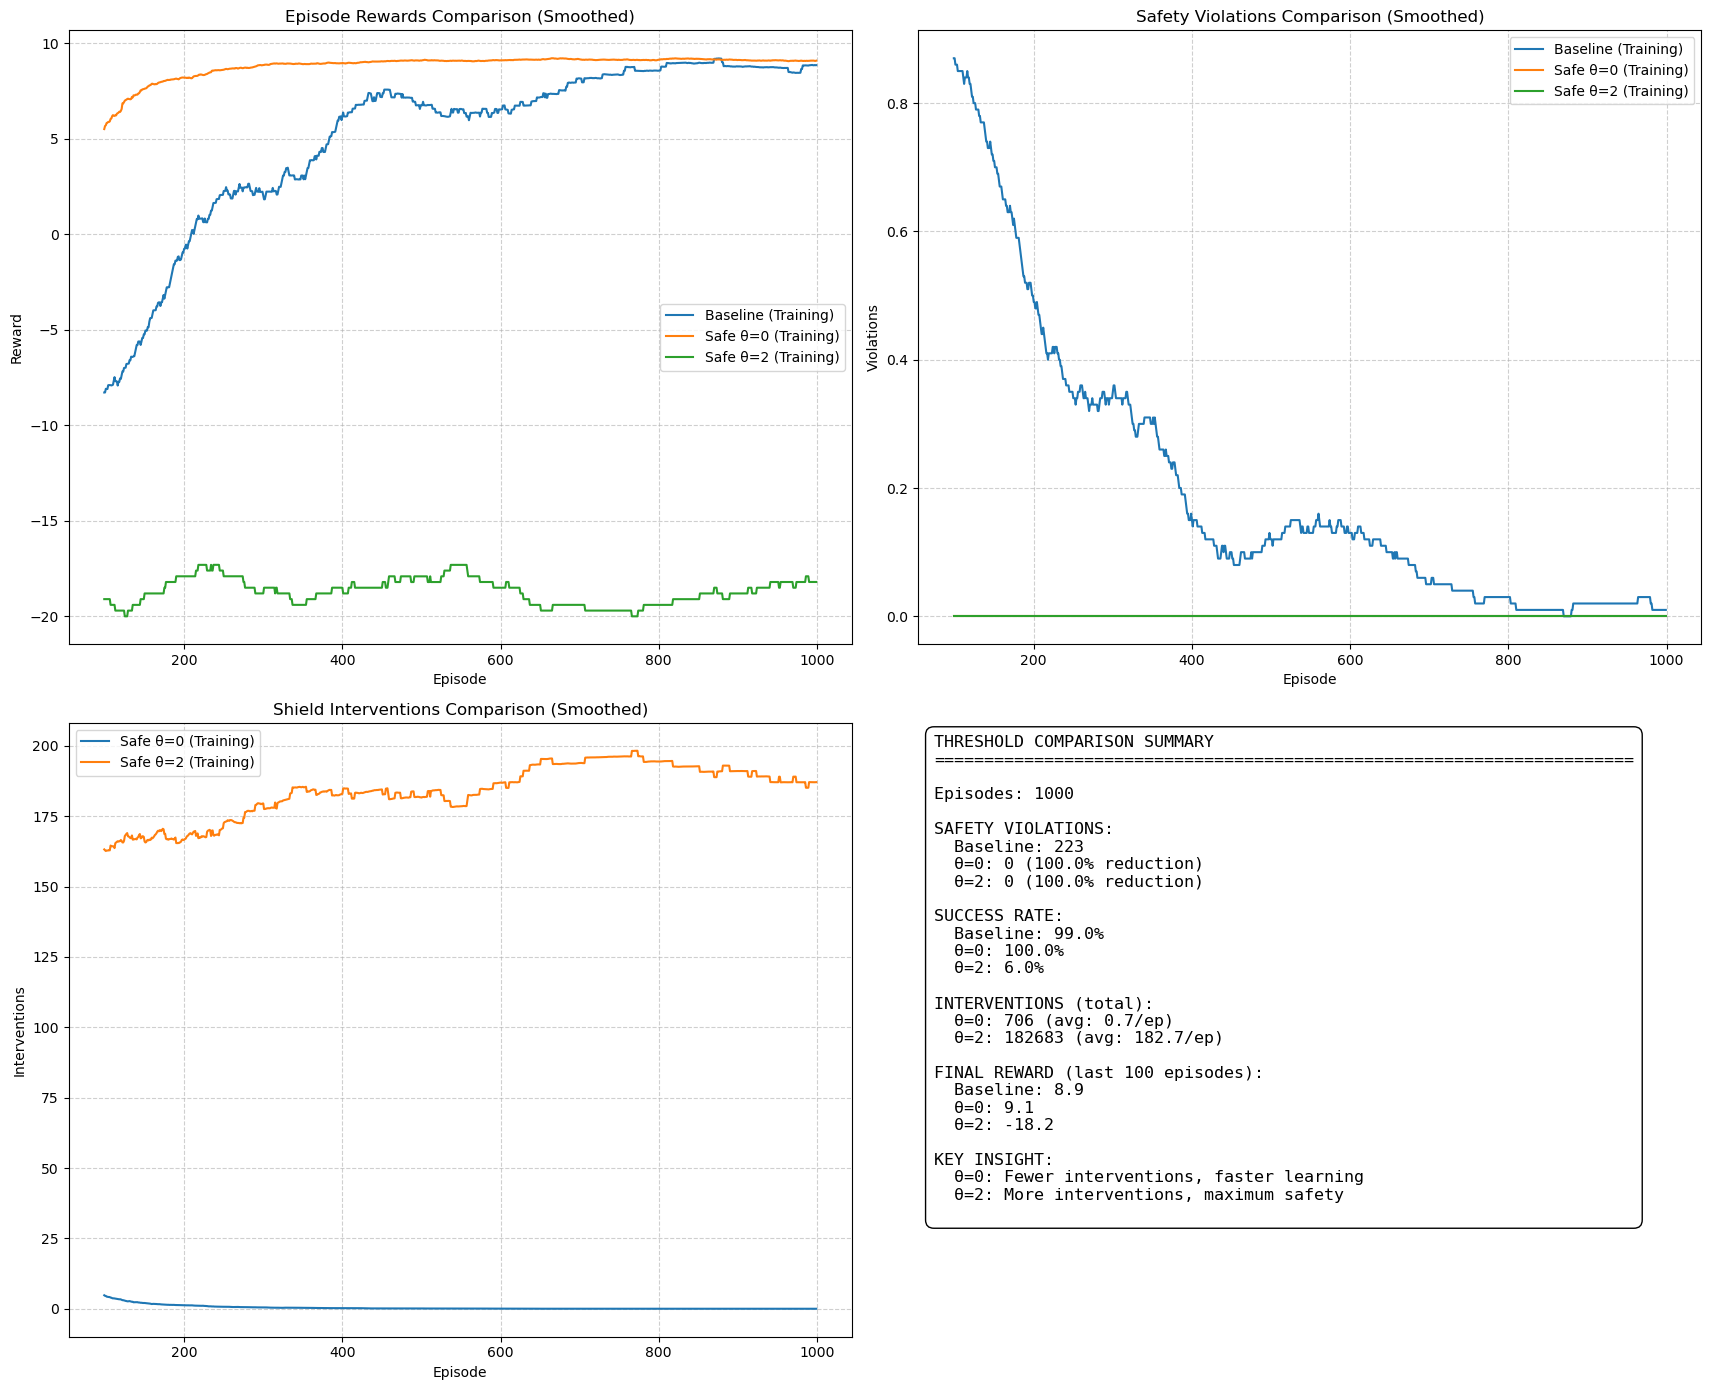


 Task 4.6: Evaluation Metrics (No Shield, Pure Greedy)
                                              Final Baseline Policy  \
Metric                                                                
Avg Reward (Last 100)                                          9.15   
Success Rate (%)                                             100.00   
Avg Length (Last 100)                                          9.51   
Total Violations (All Eps)                                     0.00   
Total Interventions (All Eps)                                  0.00   
Interventions (Last 100)                                       0.00   
Average Intervention Frequency (per episode)                   0.00   

                                              Final θ=0 Policy  \
Metric                                                           
Avg Reward (Last 100)                                     9.13   
Success Rate (%)                                        100.00   
Avg Length (Last 100)                   

In [ ]:
import numpy as np
import pickle
import torch
import torch.nn as nn
import torch.optim as optim
from collections import deque
import matplotlib.pyplot as plt
import pandas as pd


# --- From Task 4 ---
class SafetyShieldNN(nn.Module):
    def __init__(self, input_size=10, hidden_size=64, num_classes=4):
        super(SafetyShieldNN, self).__init__()
        self.layer1 = nn.Linear(input_size, hidden_size)
        self.relu1 = nn.ReLU()
        self.layer2 = nn.Linear(hidden_size, hidden_size)
        self.relu2 = nn.ReLU()
        self.output_layer = nn.Linear(hidden_size, num_classes)
        
    def forward(self, x):
        out = self.layer1(x); out = self.relu1(out)
        out = self.layer2(out); out = self.relu2(out)
        out = self.output_layer(out)
        return out

# --- From Task 2 ---
class QLearningAgent:
    def __init__(self, state_space, action_space_size, params):
        self.rows, self.cols = state_space
        self.action_space_size = action_space_size
        self.q_table = np.zeros((self.rows, self.cols, self.action_space_size))
        self.alpha = params['alpha']
        self.gamma = params['gamma']
        self.epsilon = params.get('epsilon_start', 1.0) 
        self.epsilon_min = params.get('epsilon_min', 0.01)
        self.epsilon_decay = params.get('epsilon_decay', 0.995)

    def choose_action(self, state) -> int:
        row, col = state
        if random.uniform(0, 1) < self.epsilon:
            return random.randint(0, self.action_space_size - 1)
        else:
            return np.argmax(self.q_table[row, col, :])
    
    def get_greedy_action(self, state) -> int:
        """ for validation: find best action (Epsilon=0) """
        row, col = state
        return np.argmax(self.q_table[row, col, :])

    def update_q_table(self, state, action, reward, next_state, done):
        row, col = state
        next_row, next_col = next_state
        old_q_value = self.q_table[row, col, action] 
        if done:
            future_q_max = 0.0
        else:
            future_q_max = np.max(self.q_table[next_row, next_col, :])
        td_target = reward + self.gamma * future_q_max #Temporal Difference
        new_q_value = old_q_value + self.alpha * (td_target - old_q_value)
        self.q_table[row, col, action] = new_q_value

    def decay_epsilon(self):
        self.epsilon = max(self.epsilon_min, self.epsilon * self.epsilon_decay)

# --- From Task 3 ---
def _get_next_state(env, state, action):
    dr, dc = env.actions[action]
    current_r, current_c = state
    next_r, next_c = current_r + dr, current_c + dc
    if not (0 <= next_r < env.rows and 0 <= next_c < env.cols):
        final_position = state
    else:
        final_position = (next_r, next_c)
    return final_position

def _one_hot(action, num_actions=4): #encode action
    vec = np.zeros(num_actions)
    vec[action] = 1.0
    return vec

def compute_danger_map(env): #based on multi-BFS
    danger_map = np.full(env.grid_size, np.inf)
    queue = deque()
    for h in env.hazard_cells:
        danger_map[h] = 0
        queue.append((h, 0))
    while queue:
        current_pos, distance = queue.popleft()
        for action in env.actions.keys():
            dr, dc = env.actions[action]
            nr, nc = current_pos[0] + dr, current_pos[1] + dc
            neighbor_pos = (nr, nc)
            if not (0 <= nr < env.rows and 0 <= nc < env.cols): continue
            if danger_map[neighbor_pos] == np.inf:
                danger_map[neighbor_pos] = distance + 1
                queue.append((neighbor_pos, distance + 1))
    return danger_map

# =============================================================================
# TASK 5:  CORE FUNCTIONS
# =============================================================================

def load_assets():
    """ Reload task2, task3, task4 assets"""
    try:
        q_table = np.load("task2_q_table_gentle.npy")
    except FileNotFoundError:
        print("Warning: 'task2_q_table_gentle.npy' not found. Please run Task 2 first."); raise
        
    env_temp = SafeGridWorld()
    danger_map = compute_danger_map(env_temp)
    
    model = SafetyShieldNN(input_size=10)
    try:
        model.load_state_dict(torch.load("safety_shield_model.pth"))
    except FileNotFoundError:
        print("Warning: 'safety_shield_model.pth' not found. Please run Task 4 first."); raise
    model.eval() 
    return q_table, danger_map, model, env_temp

@torch.no_grad()
def predict_risk(s, a, env, danger_map, model):
    """ shield function: get (s, a), build 10-d vector, and return risk level."""
    norm_pos = env.rows - 1.0; norm_dist = 10.0 #normalize position and distance
    r, c_col = s
    s_prime = _get_next_state(env, s, a)
    r_prime, c_prime = s_prime
    
    features = [
        r / norm_pos, c_col / norm_pos, #1-2
        *_one_hot(a, env.action_space_size), #3-6
        r_prime / norm_pos, c_prime / norm_pos, #7-8
        danger_map[s] / norm_dist, danger_map[s_prime] / norm_dist #9-10
    ]
    x_tensor = torch.tensor(features, dtype=torch.float32).unsqueeze(0) #reshape to 2d vector, define the batch size
    outputs = model(x_tensor)
    return torch.argmax(outputs).item() #return the index of the highest probability

def get_safe_action(env, agent, danger_map, model, state, theta, training_mode: bool):
    """
    implement complete intervention strategy.
    use pure greedy action when training_mode=False (evaluation).
    """
    if training_mode:
        a_prop = agent.choose_action(state) # e-greedy
    else:
        a_prop = agent.get_greedy_action(state) # get from Q-table
    
    risk_prop = predict_risk(state, a_prop, env, danger_map, model)
    if risk_prop > theta:
        return a_prop, False
    
    intervention = True
    acceptable_actions = []
    for a_candidate in range(env.action_space_size):
        risk = predict_risk(state, a_candidate, env, danger_map, model)
        if risk > theta:
            q_value = agent.q_table[state[0], state[1], a_candidate]
            acceptable_actions.append((a_candidate, q_value))
            
    if acceptable_actions:
        acceptable_actions.sort(key=lambda x: x[1], reverse=True)
        return acceptable_actions[0][0], intervention

    #All dangerous actions
    least_bad_actions = []
    max_risk = -1
    all_risks = [predict_risk(state, a, env, danger_map, model) for a in range(4)]
    max_risk = max(all_risks)
    
    for a_candidate, risk in enumerate(all_risks):
        if risk == max_risk:
            q_value = agent.q_table[state[0], state[1], a_candidate]
            least_bad_actions.append((a_candidate, q_value))

    least_bad_actions.sort(key=lambda x: x[1], reverse=True)
    return least_bad_actions[0][0], intervention



def run_safe_rl_session(params, agent, danger_map, model, theta, 
                        run_type='safe', training_mode=True, n_episodes=1000, label=""):
    """
    training_mode=True:   e-greedy, update Q-Table, decay epsilon.
    training_mode=False:  pure greedy, not update Q-Table, not decay epsilon.
    """
    if not label:
        label = f"Baseline" if run_type == 'baseline' else f"Safe (theta={theta})"
    
    mode_str = "TRAINING" if training_mode else "EVALUATION"
    
    env = SafeGridWorld(random_start=True) # 
    
    log_rewards, log_lengths, log_violations, log_interventions = [], [], [], []
    start_time = time.time()
    
    for episode in range(n_episodes):
        state = env.reset()
        total_reward, steps, violations, interventions = 0, 0, 0, 0
        done = False
        
        while not done and steps < params['MAX_STEPS']:
            
            if run_type == 'baseline':
                if training_mode:
                    a_executed = agent.choose_action(state)
                else:
                    a_executed = agent.get_greedy_action(state)
            else:
                a_executed, intervened = get_safe_action(env, agent, danger_map, model, state, theta, training_mode)
                if intervened:
                    interventions += 1
            
            next_state, reward, done = env.step(a_executed)
            
            if training_mode:
                agent.update_q_table(state, a_executed, reward, next_state, done)
            
            total_reward += reward
            steps += 1
            state = next_state
            if reward == env.hazard_reward:
                violations += 1
                
        if training_mode:
            agent.decay_epsilon()
            
        log_rewards.append(total_reward); log_lengths.append(steps)
        log_violations.append(violations); log_interventions.append(interventions)

    
    results = {
        'rewards': np.array(log_rewards), 'lengths': np.array(log_lengths),
        'violations': np.array(log_violations), 'interventions': np.array(log_interventions),
        'label': label
    }
    return results, agent # return agent for later evaluation

# =============================================================================
# Task 5 / 4.6: PLOTTING & METRICS
# =============================================================================

def plot_task5_results(baseline_res, safe_res_t0, safe_res_t2, df_summary, window_size=100):
    """
    Visualize the results of Task 5.
    """

    fig, axes = plt.subplots(2, 2, figsize=(18, 14))

    all_results = [baseline_res, safe_res_t0, safe_res_t2]

    ax = axes[1, 1]

    # Extract values from df_summary to build a fixed-format text block
    episodes = df_summary.loc[('EPISODES', ''), 'Result']

    b_viol = df_summary.loc[('SAFETY VIOLATIONS', 'Baseline'), 'Result']
    t0_viol = df_summary.loc[('SAFETY VIOLATIONS', 'θ=0'), 'Result']
    t2_viol = df_summary.loc[('SAFETY VIOLATIONS', 'θ=2'), 'Result']

    b_succ = df_summary.loc[('SUCCESS RATE', 'Baseline'), 'Result']
    t0_succ = df_summary.loc[('SUCCESS RATE', 'θ=0'), 'Result']
    t2_succ = df_summary.loc[('SUCCESS RATE', 'θ=2'), 'Result']

    t0_int = df_summary.loc[('INTERVENTIONS (total)', 'θ=0'), 'Result']
    t2_int = df_summary.loc[('INTERVENTIONS (total)', 'θ=2'), 'Result']

    b_rew = df_summary.loc[('FINAL REWARD (last 100 episodes)', 'Baseline'), 'Result']
    t0_rew = df_summary.loc[('FINAL REWARD (last 100 episodes)', 'θ=0'), 'Result']
    t2_rew = df_summary.loc[('FINAL REWARD (last 100 episodes)', 'θ=2'), 'Result']

    header = 'THRESHOLD COMPARISON SUMMARY\n' + '='*70
    block = f"""

Episodes: {episodes}

SAFETY VIOLATIONS:
  Baseline: {b_viol}
  θ=0: {t0_viol}
  θ=2: {t2_viol}

SUCCESS RATE:
  Baseline: {b_succ}
  θ=0: {t0_succ}
  θ=2: {t2_succ}

INTERVENTIONS (total):
  θ=0: {t0_int}
  θ=2: {t2_int}

FINAL REWARD (last 100 episodes):
  Baseline: {b_rew}
  θ=0: {t0_rew}
  θ=2: {t2_rew}

KEY INSIGHT:
  θ=0: Fewer interventions, faster learning
  θ=2: More interventions, maximum safety
"""
    summary_text = header + block

    ax.text(0.02, 0.98, summary_text,
            horizontalalignment='left',
            verticalalignment='top',
            fontsize=12,
            fontfamily='monospace',
            transform=ax.transAxes,
            bbox=dict(boxstyle="round,pad=0.5", fc='white', ec='black'))
    ax.axis('off')

    ax = axes[0, 0] 
    ax.set_title('Episode Rewards Comparison (Smoothed)')
    ax.set_ylabel('Reward')
    ax.set_xlabel('Episode') 
    for res in all_results: 
        ax.plot(pd.Series(res['rewards']).rolling(window_size).mean(), label=res['label'])
    ax.legend()
    ax.grid(True, linestyle='--', alpha=0.6)


    ax = axes[0, 1]
    ax.set_title('Safety Violations Comparison (Smoothed)')
    ax.set_ylabel('Violations')
    ax.set_xlabel('Episode')
    for res in all_results: 
        ax.plot(pd.Series(res['violations']).rolling(window_size).mean(), label=res['label'])
    ax.legend()
    ax.grid(True, linestyle='--', alpha=0.6)

    ax = axes[1, 0]
    ax.set_title('Shield Interventions Comparison (Smoothed)')
    ax.set_xlabel('Episode')
    ax.set_ylabel('Interventions')

    for res in all_results[1:]: 
        ax.plot(pd.Series(res['interventions']).rolling(window_size).mean(), label=res['label'])
    ax.legend()
    ax.grid(True, linestyle='--', alpha=0.6)

    plt.tight_layout()
    
    plt.show()

def calculate_task_metrics(results, n_episodes, last_M_episodes):
    """ Calculate the summary metrics of Task 5 and 4.6."""
    last_M_rewards = results['rewards'][-last_M_episodes:]
    last_M_lengths = results['lengths'][-last_M_episodes:]
    last_M_violations = results['violations'][-last_M_episodes:]
    
    success_rate = np.mean((last_M_rewards > 0) & (last_M_violations == 0)) * 100
    avg_reward = np.mean(last_M_rewards)
    avg_length = np.mean(last_M_lengths)
    total_violations = np.sum(results['violations'])
    total_interventions = np.sum(results['interventions'])
    interventions_last_100 = np.sum(results['interventions'][-100:])
    
    metrics = {
        f'Avg Reward (Last {last_M_episodes})': avg_reward, #4.6 Task Performance 1
        'Success Rate (%)': success_rate, #4.6 Task Performance 2
        f'Avg Length (Last {last_M_episodes})': avg_length, #4.6 Task Performance 3
        'Total Violations (All Eps)': total_violations, 
        'Total Interventions (All Eps)': total_interventions, #4.6 Intervention Efficiency 1
        'Interventions (Last 100)': interventions_last_100, #4.6 Intervention Efficiency 2
        'Average Intervention Frequency (per episode)': total_interventions / n_episodes #4.6 Intervention Efficiency 3
    }
    return metrics

def format_summary_table(metrics_b, metrics_t0, metrics_t2, N_episodes, M_last_episodes):
    episodes = N_episodes
    b_viol = metrics_b['Total Violations (All Eps)']
    t0_viol = metrics_t0['Total Violations (All Eps)']
    t2_viol = metrics_t2['Total Violations (All Eps)']
    
    b_succ = metrics_b['Success Rate (%)']
    t0_succ = metrics_t0['Success Rate (%)']
    t2_succ = metrics_t2['Success Rate (%)']
    
    t0_int = metrics_t0['Total Interventions (All Eps)']
    t2_int = metrics_t2['Total Interventions (All Eps)']
    
    b_rew = metrics_b[f'Avg Reward (Last {M_last_episodes})']
    t0_rew = metrics_t0[f'Avg Reward (Last {M_last_episodes})']
    t2_rew = metrics_t2[f'Avg Reward (Last {M_last_episodes})']

    viol_reduction_t0 = (1.0 - t0_viol / b_viol) * 100 if b_viol > 0 else 100.0
    viol_reduction_t2 = (1.0 - t2_viol / b_viol) * 100 if b_viol > 0 else 100.0
    avg_int_t0 = t0_int / N_episodes
    avg_int_t2 = t2_int / N_episodes

    index = [
        ('EPISODES', ''),
        ('SAFETY VIOLATIONS', 'Baseline'), ('SAFETY VIOLATIONS', 'θ=0'), ('SAFETY VIOLATIONS', 'θ=2'),
        ('SUCCESS RATE', 'Baseline'), ('SUCCESS RATE', 'θ=0'), ('SUCCESS RATE', 'θ=2'),
        ('INTERVENTIONS (total)', 'θ=0'), ('INTERVENTIONS (total)', 'θ=2'),
        ('FINAL REWARD (last 100 episodes)', 'Baseline'), ('FINAL REWARD (last 100 episodes)', 'θ=0'), ('FINAL REWARD (last 100 episodes)', 'θ=2'),
    ]
    df_index = pd.MultiIndex.from_tuples(index, names=["Metric", "Configuration"])
    
    data = [
        f"{episodes}",
        f"{b_viol:.0f}", f"{t0_viol:.0f} ({viol_reduction_t0:.1f}% reduction)", f"{t2_viol:.0f} ({viol_reduction_t2:.1f}% reduction)",
        f"{b_succ:.1f}%", f"{t0_succ:.1f}%", f"{t2_succ:.1f}%",
        f"{t0_int:.0f} (avg: {avg_int_t0:.1f}/ep)", f"{t2_int:.0f} (avg: {avg_int_t2:.1f}/ep)",
        f"{b_rew:.1f}", f"{t0_rew:.1f}", f"{t2_rew:.1f}",
    ]
    return pd.DataFrame(data, index=df_index, columns=["Result"])

# =============================================================================
# Task 5 / 4.6: MAIN EXECUTION
# =============================================================================

PARAMS_TRAIN = {
    'alpha': 0.1, 'gamma': 0.99, 'epsilon_start': 1.0,
    'epsilon_min': 0.01, 'epsilon_decay': 0.995,
    'MAX_STEPS': 200,
    'random_seed': 66
}
N_TRAIN_EPISODES = 1000 
M_last_episodes = 100 
N_EVAL_EPISODES = 100

torch.manual_seed(PARAMS_TRAIN['random_seed'])
np.random.seed(PARAMS_TRAIN['random_seed'])


initial_q_table, danger_map, shield_model, env_ref = load_assets()

agent_baseline = QLearningAgent(env_ref.grid_size, env_ref.action_space_size, PARAMS_TRAIN); agent_baseline.q_table = np.copy(initial_q_table)
agent_safe_t0 = QLearningAgent(env_ref.grid_size, env_ref.action_space_size, PARAMS_TRAIN); agent_safe_t0.q_table = np.copy(initial_q_table)
agent_safe_t2 = QLearningAgent(env_ref.grid_size, env_ref.action_space_size, PARAMS_TRAIN); agent_safe_t2.q_table = np.copy(initial_q_table)

train_res_b, final_agent_b = run_safe_rl_session(
    PARAMS_TRAIN, agent_baseline, danger_map, None, 
    theta=None, run_type='baseline', training_mode=True, n_episodes=N_TRAIN_EPISODES, label="Baseline (Training)"
)
train_res_t0, final_agent_t0 = run_safe_rl_session(
    PARAMS_TRAIN, agent_safe_t0, danger_map, shield_model, 
    theta=0, run_type='safe', training_mode=True, n_episodes=N_TRAIN_EPISODES, label="Safe θ=0 (Training)"
)
train_res_t2, final_agent_t2 = run_safe_rl_session(
    PARAMS_TRAIN, agent_safe_t2, danger_map, shield_model, 
    theta=2, run_type='safe', training_mode=True, n_episodes=N_TRAIN_EPISODES, label="Safe θ=2 (Training)"
)


eval_res_b, _ = run_safe_rl_session(
    PARAMS_TRAIN, final_agent_b, danger_map, None, 
    theta=None, run_type='baseline', training_mode=False, n_episodes=N_EVAL_EPISODES, label="Final Baseline Policy"
)
eval_res_t0, _ = run_safe_rl_session(
    PARAMS_TRAIN, final_agent_t0, danger_map, shield_model, 
    theta=None, run_type='baseline', training_mode=False, n_episodes=N_EVAL_EPISODES, label="Final θ=0 Policy"
)
eval_res_t2, _ = run_safe_rl_session(
    PARAMS_TRAIN, final_agent_t2, danger_map, shield_model, 
    theta=None, run_type='baseline', training_mode=False, n_episodes=N_EVAL_EPISODES, label="Final θ=2 Policy"
)

# ---  Calculate metrics (training & evaluation) ---
metrics_b_train = calculate_task_metrics(train_res_b, N_TRAIN_EPISODES, M_last_episodes)
metrics_t0_train = calculate_task_metrics(train_res_t0, N_TRAIN_EPISODES, M_last_episodes)
metrics_t2_train = calculate_task_metrics(train_res_t2, N_TRAIN_EPISODES, M_last_episodes)

metrics_b_eval = calculate_task_metrics(eval_res_b, N_EVAL_EPISODES, N_EVAL_EPISODES)
metrics_t0_eval = calculate_task_metrics(eval_res_t0, N_EVAL_EPISODES, N_EVAL_EPISODES)
metrics_t2_eval = calculate_task_metrics(eval_res_t2, N_EVAL_EPISODES, N_EVAL_EPISODES)


df_summary = format_summary_table(metrics_b_train, metrics_t0_train, metrics_t2_train, N_TRAIN_EPISODES, M_last_episodes)

plot_task5_results(train_res_b, train_res_t0, train_res_t2, df_summary, window_size=100)

# ---- Print evaluation metrics as a DataFrame ----
print("\n" + "="*50)
print(" Task 4.6: Evaluation Metrics (No Shield, Pure Greedy)")
print("="*50)

df_eval_metrics = pd.DataFrame({
    'Metric': list(metrics_b_eval.keys()),
    'Final Baseline Policy': list(metrics_b_eval.values()),
    'Final θ=0 Policy': list(metrics_t0_eval.values()),
    'Final θ=2 Policy': list(metrics_t2_eval.values())
}).set_index('Metric')

pd.set_option('display.float_format', '{:.2f}'.format)
print(df_eval_metrics)



### My analysis for Task5 and Evaluate metrics
- Episode Rewards: 
    - Baseline need to learn a lot then can go to correct state
    - Theta 0 nearly need learn can find the goal, because of the choice of action supervised by mlp neurous network predictions that can find good actions.
    - Theta 2 never arrive the goal. Because it's too strict to supervisor the agent. Too safe.

- Safety violation comparison:
    - After learning, Baseline violation decrease obviously
    - Theta 0 & 2 because of safty sheild violation still = 0

- Shield intervention comparison:
    - Theta 0 almost = 0, but first 100 episode is not 0. The reason maybe is epsilon. When starting, epsilon is high, The agent more like to explore. So maybe do some action go to class 0 state, Then interventioned by safety shield.
    - Theta 2 have lots of interventions because Theta 2 is too strict to agent. It's hardly find some state class > 2. Too safe not means good.

From summary, baseline can learn a good way to find goal but not absolutely safe. Theta 0 have fewer interventions that can lean faster. Theta 2 have more interventions with maximum safety but learning slow. And too safety to less success rate.

Across the experiment, RL(Q-learning) + mlp + safety shield Theta 0 is better.